# 📊 **Exploratory Data Analysis — BTC Price × ETH Cross-Features**

### 🎯 **Objective**
Assess whether **Ethereum market features** add useful signal on top of BTC market features for BTC crash prediction.

### ⚠️ **Target Definition**
A crash is defined as a price drop of more than **10% within the next 7 days** — the same definition as in notebook 01 (BTC EDA).

- `1` → Crash
- `0` → No crash

### 🔬 **EDA Focus**
1. Merge BTC and ETH daily price datasets on date
2. Rename ETH columns with `_eth` suffix to avoid conflicts (ETH target is dropped)
3. Measure linear, monotonic, and non-linear dependencies of ETH features with the BTC target
4. Select ETH cross-features using a combined score (Spearman + MI)
5. Build a compact feature set for benchmarking

### 🚀 **Goal**
Determine whether **ETH market variables** bring complementary information for predicting BTC crashes — and if so, which ones. BTC and ETH are highly correlated assets; the hypothesis is that ETH momentum or volatility dynamics may lead BTC reversal signals.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

In [14]:
df_btc = pd.read_csv("../../data/gold/market/btc_usdt_1d_features.csv")
df_eth = pd.read_csv("../../data/gold/market/eth_usdt_1d_features.csv")

### 1. Initial Data Overview

In [15]:
df_eth.head()

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,lag_volume_norm,lag_buy_pressure,momentum_acc,volatility_ratio,momentum_volatility,pressure_x_return,ma_7,ma_30,ma_ratio,target
0,2017-09-16,255.99,271.81,235.51,249.31,10362.06011,2.647152e+06,8859,3866.60141,995005.326705,...,2.382383,0.418015,-0.190181,1.514538,-0.018696,-0.005442,268.455714,315.714667,0.850311,False
1,2017-09-17,249.32,264.39,239.02,257.55,4614.53337,1.149704e+06,5277,1442.00382,360268.473861,...,1.703868,0.373150,0.047636,1.532832,-0.014528,0.010328,263.320000,314.501000,0.837263,False
2,2017-09-18,257.53,306.22,257.11,294.57,4125.97051,1.182938e+06,3440,2342.68408,669740.521499,...,0.779827,0.312492,0.110688,1.623058,-0.001218,0.081614,262.930000,314.623000,0.835699,True
3,2017-09-19,296.00,300.00,277.41,284.00,1869.90852,5.357736e+05,1896,789.82937,226839.706542,...,0.689572,0.567790,-0.179622,1.630211,-0.004525,-0.015157,261.507143,314.119667,0.832508,False
4,2017-09-20,284.01,294.00,275.91,282.00,1060.56734,3.027397e+05,1431,566.64637,162290.418587,...,0.313636,0.422389,0.028841,1.626730,0.002409,-0.003763,262.234286,312.743333,0.838497,False


In [16]:
print(f"{df_btc.shape[0]} rows and {df_btc.shape[1]} columns in the BTC price dataset.")
print(f"{df_eth.shape[0]} rows and {df_eth.shape[1]} columns in the ETH price dataset.")

3115 rows and 30 columns in the BTC price dataset.
3114 rows and 30 columns in the ETH price dataset.


**Observation:**
Both datasets share the same column structure and cover daily OHLCV + engineered features.
ETH columns will be renamed with the `_eth` suffix before merging so that only the BTC target is used as the prediction objective.

**Impact:**
The inner join on `open_time` will retain dates present in both datasets. Both cover approximately the same period (from 2017), so overlap should be nearly complete.

### 2. Time Alignment and Merge

In [17]:
df_btc["open_time"] = pd.to_datetime(df_btc["open_time"], errors="coerce")
df_eth["open_time"] = pd.to_datetime(df_eth["open_time"], errors="coerce")

print(f"BTC price range: {df_btc['open_time'].min().date()} to {df_btc['open_time'].max().date()}")
print(f"ETH price range: {df_eth['open_time'].min().date()} to {df_eth['open_time'].max().date()}")

BTC price range: 2017-09-16 to 2026-03-27
ETH price range: 2017-09-16 to 2026-03-26


**Observation:**
Both series use the same ISO date format — no offset correction is needed. The inner join will naturally restrict to the common window.

**Conclusion:**
Date alignment is straightforward. Any small discrepancy at the extremes (first/last available date) will be handled by the inner join.

### 3. Merged BTC + ETH Cross Dataset

In [18]:
# Rename ETH columns with _eth suffix (except open_time used as join key)
eth_renamed = df_eth.rename(columns={c: f"{c}_eth" for c in df_eth.columns if c != "open_time"})

# Merge — inner join on open_time
df_merged = pd.merge(df_btc, eth_renamed, on="open_time", how="inner")

# Drop ETH target (not the prediction objective here)
df_merged.drop(columns=["target_eth", "open_time"], inplace=True)

print(f"Merged dataset: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")
df_merged.head()

Merged dataset: 3114 rows, 57 columns


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return_1d,...,lag_volatility_7d_eth,lag_volume_norm_eth,lag_buy_pressure_eth,momentum_acc_eth,volatility_ratio_eth,momentum_volatility_eth,pressure_x_return_eth,ma_7_eth,ma_30_eth,ma_ratio_eth
0,3674.01,3950.00,3470.66,3714.95,1297.563953,4.804878e+06,8809,624.887842,2.314536e+06,0.004041,...,0.116960,2.382383,0.418015,-0.190181,1.514538,-0.018696,-0.005442,268.455714,315.714667,0.850311
1,3685.23,3748.21,3499.02,3699.99,682.171210,2.466490e+06,6355,273.931976,9.948436e+05,-0.004027,...,0.116971,1.703868,0.373150,0.047636,1.532832,-0.014528,0.010328,263.320000,314.501000,0.837263
2,3690.00,4123.20,3690.00,4035.01,1030.006455,4.069033e+06,8220,417.638722,1.651863e+06,0.090546,...,0.118611,0.779827,0.312492,0.110688,1.623058,-0.001218,0.081614,262.930000,314.623000,0.835699
3,4060.00,4089.97,3830.91,3910.04,902.332129,3.558315e+06,7342,257.320352,1.016804e+06,-0.030971,...,0.132689,0.689572,0.567790,-0.179622,1.630211,-0.004525,-0.015157,261.507143,314.119667,0.832508
4,3910.04,4046.08,3820.00,3900.00,720.935076,2.839584e+06,7231,395.275138,1.562210e+06,-0.002568,...,0.133563,0.313636,0.422389,0.028841,1.626730,0.002409,-0.003763,262.234286,312.743333,0.838497


**Observations:**
- The merged dataset contains **3 114 rows** covering **2017-09-16 to 2026-03-26**, limited by ETH's last available date (BTC extends one extra day to 2026-03-27).
- After renaming, ETH columns carry the `_eth` suffix: 28 ETH features + 29 BTC features = **57 columns** total.
- `target_eth` and `open_time` are dropped — only the **BTC crash indicator** is kept as prediction target.
- No missing values after the inner join.

**Conclusion:**
The merged dataset is clean and represents a nearly perfect date overlap between the two assets. Feature naming is unambiguous, making correlation analysis straightforward.

### 4. Correlation Between Features and Target

**Objective**
Identify which ETH cross-features carry signal for BTC crash prediction, using three complementary views:
- Pearson for linear effects
- Spearman for monotonic effects
- Mutual Information for non-linear dependencies

**Pearson Correlation with Target**

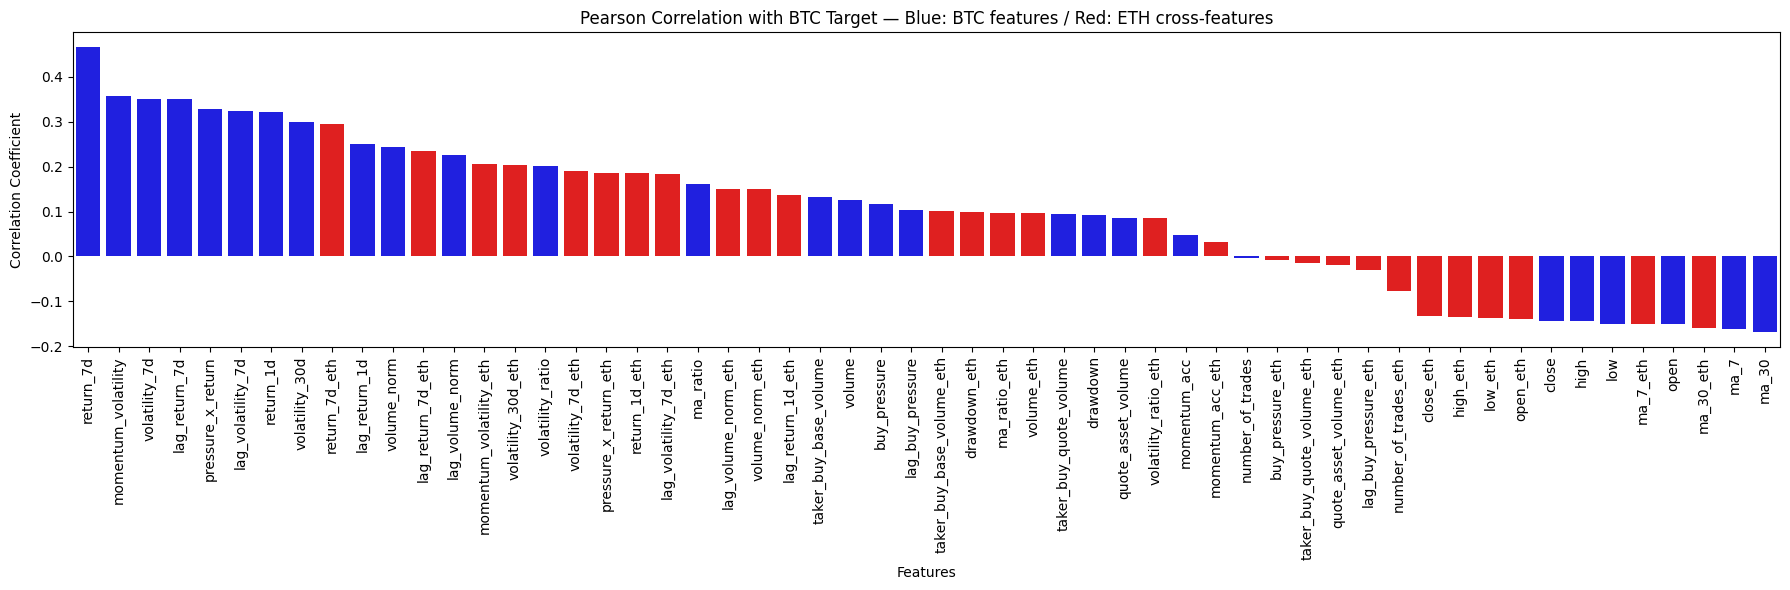

In [19]:
# Define cross-asset columns (ETH features)
cross_cols = [c for c in df_merged.columns if c.endswith("_eth")]

corrs_pearson = (
    df_merged
    .corr(method="pearson", numeric_only=True)["target"]
    .sort_values(ascending=False)
    .drop("target")
)

colors = ["red" if col in cross_cols else "blue" for col in corrs_pearson.index]

plt.figure(figsize=(18, 6))
sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values,
            hue=corrs_pearson.index, palette=dict(zip(corrs_pearson.index, colors)), legend=False)
plt.xticks(rotation=90)
plt.title("Pearson Correlation with BTC Target — Blue: BTC features / Red: ETH cross-features")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

**Observations:**
- Pearson correlation with the BTC crash target is generally weak for both BTC and ETH features, which is expected for a binary crash indicator against continuous features.
- Among ETH cross-features (red bars), **`return_7d_eth`**, **`lag_return_7d_eth`**, and **`momentum_volatility_eth`** stand out with the highest absolute Pearson values, consistent with their BTC counterparts.
- Raw price and volume columns (`open_eth`, `close_eth`, `high_eth`, `low_eth`, `volume_eth`, etc.) show very low Pearson correlation, as expected for unscaled absolute levels.
- The ETH and BTC feature bars mirror each other closely, confirming the high co-movement between the two assets.

**Conclusion:**
Pearson correlation alone is insufficient for feature selection given the non-linear nature of crash events. Spearman and MI will provide a more complete picture.

**Spearman Correlation with Target**

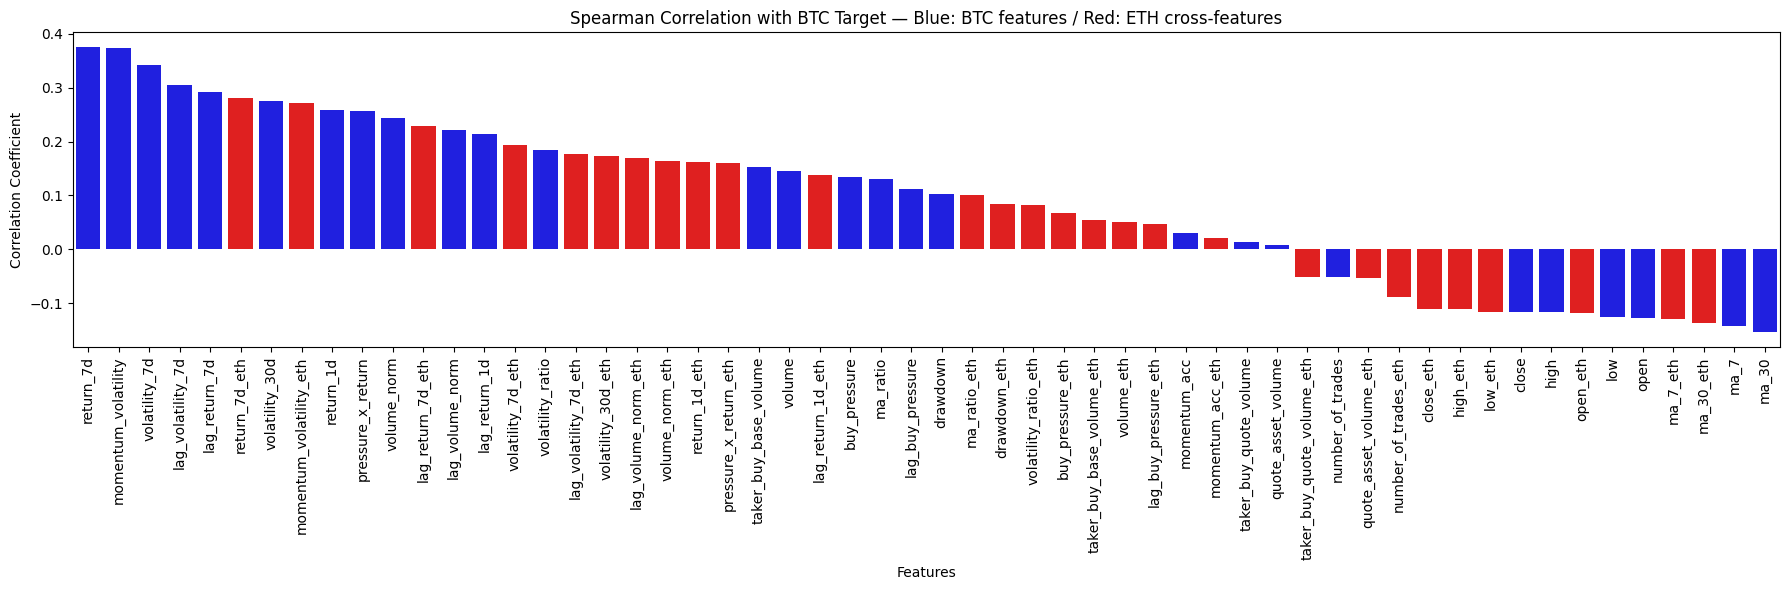

In [20]:
corrs_spearman = (
    df_merged
    .corr(method="spearman", numeric_only=True)["target"]
    .sort_values(ascending=False)
    .drop("target")
)
colors = ["red" if col in cross_cols else "blue" for col in corrs_spearman.index]

plt.figure(figsize=(18, 6))
sns.barplot(x=corrs_spearman.index, y=corrs_spearman.values,
            hue=corrs_spearman.index, palette=dict(zip(corrs_spearman.index, colors)), legend=False)
plt.xticks(rotation=90)
plt.title("Spearman Correlation with BTC Target — Blue: BTC features / Red: ETH cross-features")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

**Observations:**
- Spearman correlation is more informative than Pearson for this binary target.
- ETH cross-features (red bars) closely shadow their BTC counterparts, reflecting the strong structural correlation between the two assets' market dynamics.
- **`return_7d_eth`**, **`lag_return_7d_eth`**, and **`momentum_volatility_eth`** consistently rank among the top ETH cross-features, confirming they carry real monotonic signal for BTC crash prediction.
- The agreement between BTC and ETH rankings reinforces that ETH market behaviour broadly tracks BTC — when BTC is under stress, ETH features reflect it too.

**Conclusion:**
Spearman correlation confirms that ETH return and volatility features share meaningful monotonic relationships with BTC crash events. This justifies their inclusion as cross-asset predictors.

**Mutual Information with Target**

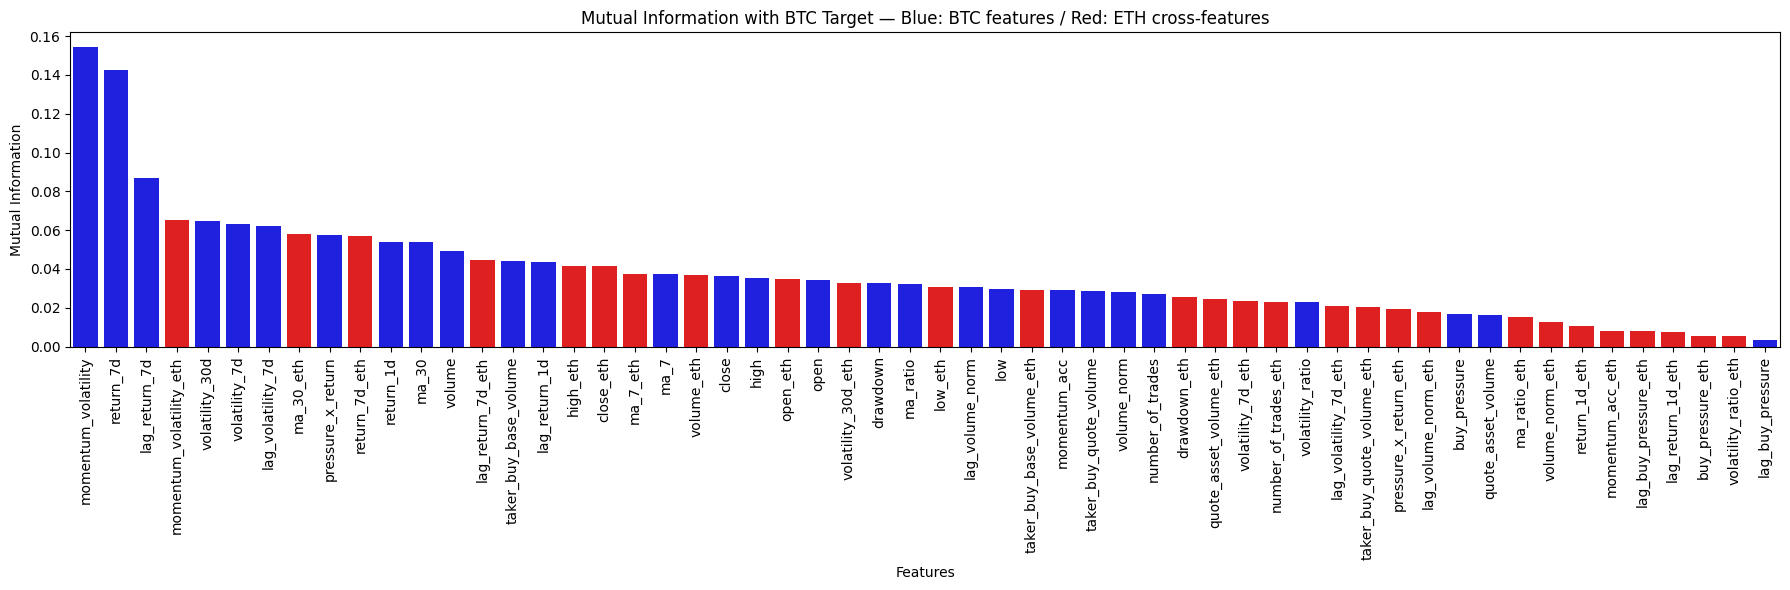

momentum_volatility           0.154257
return_7d                     0.142525
lag_return_7d                 0.087011
momentum_volatility_eth       0.065351
volatility_30d                0.064794
volatility_7d                 0.063388
lag_volatility_7d             0.062036
ma_30_eth                     0.057805
pressure_x_return             0.057299
return_7d_eth                 0.057224
return_1d                     0.053959
ma_30                         0.053722
volume                        0.049153
lag_return_7d_eth             0.044459
taker_buy_base_volume         0.044221
lag_return_1d                 0.043688
high_eth                      0.041604
close_eth                     0.041554
ma_7_eth                      0.037614
ma_7                          0.037219
volume_eth                    0.036796
close                         0.036346
high                          0.035106
open_eth                      0.034650
open                          0.034138
volatility_30d_eth       

In [21]:
X = df_merged.drop(columns=["target"])
y = df_merged["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mutual_info = mutual_info_classif(X_scaled, y, discrete_features=False, n_neighbors=5, random_state=42)
mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)

colors_mi = ["red" if col in cross_cols else "blue" for col in mutual_info_series.index]

plt.figure(figsize=(18, 6))
sns.barplot(x=mutual_info_series.index, y=mutual_info_series.values,
            hue=mutual_info_series.index, palette=dict(zip(mutual_info_series.index, colors_mi)), legend=False)
plt.xticks(rotation=90)
plt.title("Mutual Information with BTC Target — Blue: BTC features / Red: ETH cross-features")
plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

mutual_info_series

**Observations:**
- Mutual Information values confirm moderate non-linear signal from ETH cross-features for BTC crash prediction.
- Top ETH cross-features by MI: **`momentum_volatility_eth`** (0.065), **`return_7d_eth`** (0.057), **`lag_return_7d_eth`** (0.044), **`ma_30_eth`** (0.058).
- These values are comparable to — and sometimes exceed — some BTC features, indicating that ETH market dynamics carry independent predictive information beyond what BTC features already capture.
- Lower-MI ETH features (`volatility_ratio_eth`, `buy_pressure_eth`, `momentum_acc_eth`) still clear the threshold via Spearman, showing the importance of combining both signals.
- The top BTC feature by MI is `momentum_volatility` (0.154), approximately 2.4× the top ETH cross-feature MI — confirming BTC's own features remain the primary signal source.

**Conclusion:**
ETH cross-features contribute genuine non-linear signal for BTC crash prediction. Their MI values are not negligible and justify including them in the cross-asset model alongside BTC features.

**Combined Score — ETH Cross-Feature Ranking**

To select ETH cross-features in a principled and consistent way with notebooks 04 and 05, a **combined score** is computed for each ETH feature:

$$\text{score} = \frac{|\rho_{\text{Spearman}}|}{\max(|\rho_{\text{Spearman}}|)} + \frac{\text{MI}}{\max(\text{MI})}$$

- Each term is **normalized to [0, 1]** against the maximum across *all features* (BTC + ETH), so the scale reflects how an ETH feature compares to the strongest signal in the dataset.
- The combined score ranges from **0 to 2**: 2 means the feature is best-in-class on both metrics simultaneously.
- The threshold **0.10** is used consistently with notebooks 04 and 05.

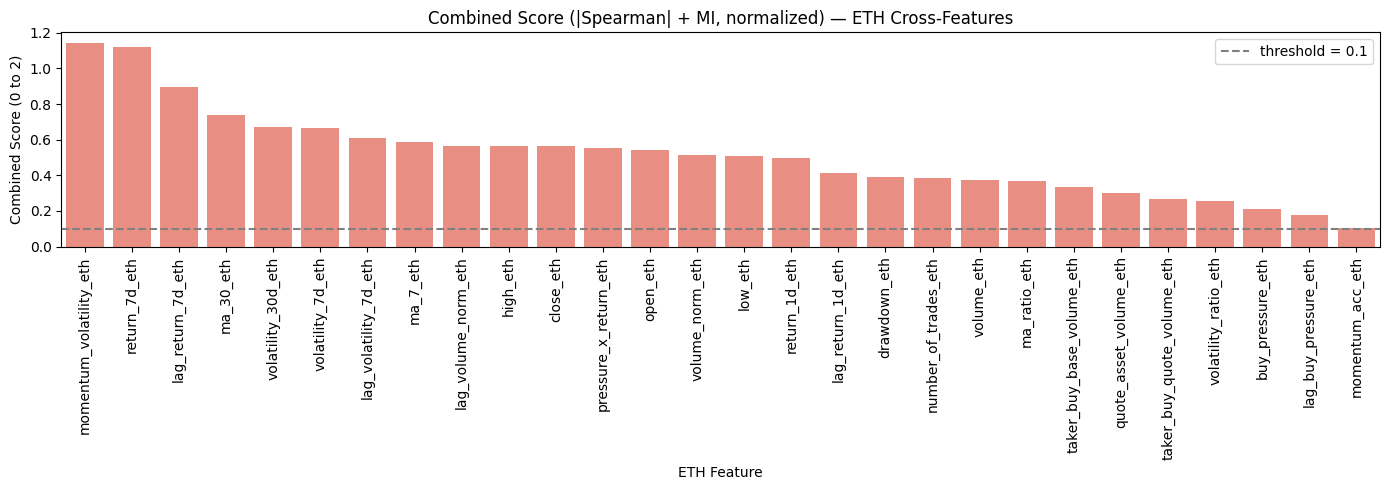

momentum_volatility_eth       1.145358
return_7d_eth                 1.119583
lag_return_7d_eth             0.894271
ma_30_eth                     0.739550
volatility_30d_eth            0.670439
volatility_7d_eth             0.663187
lag_volatility_7d_eth         0.607764
ma_7_eth                      0.587732
lag_volume_norm_eth           0.566877
high_eth                      0.564703
close_eth                     0.562236
pressure_x_return_eth         0.553067
open_eth                      0.539756
volume_norm_eth               0.515342
low_eth                       0.507404
return_1d_eth                 0.497303
lag_return_1d_eth             0.414297
drawdown_eth                  0.388980
number_of_trades_eth          0.384858
volume_eth                    0.372775
ma_ratio_eth                  0.365776
taker_buy_base_volume_eth     0.336235
quote_asset_volume_eth        0.300640
taker_buy_quote_volume_eth    0.268117
volatility_ratio_eth          0.254996
buy_pressure_eth         

In [22]:
cross_score = (
    corrs_spearman.abs() / corrs_spearman.abs().max()
    + mutual_info_series / mutual_info_series.max()
)[cross_cols].sort_values(ascending=False)

CROSS_SCORE_THRESHOLD = 0.10

plt.figure(figsize=(14, 5))
sns.barplot(x=cross_score.index, y=cross_score.values, color="salmon")
plt.axhline(y=CROSS_SCORE_THRESHOLD, color="gray", linestyle="--", linewidth=1.5,
            label=f"threshold = {CROSS_SCORE_THRESHOLD}")
plt.xticks(rotation=90)
plt.title("Combined Score (|Spearman| + MI, normalized) — ETH Cross-Features")
plt.ylabel("Combined Score (0 to 2)")
plt.xlabel("ETH Feature")
plt.legend()
plt.tight_layout()
plt.show()

cross_score

**Observations:**
- Combined scores range from **1.145** (`momentum_volatility_eth`) down to **0.107** (`momentum_acc_eth`).
- **All 28 ETH features exceed the 0.10 threshold** — there is no natural gap above 0.10.  The lowest-scoring feature, `momentum_acc_eth` (0.107), still marginally clears the bar.
- The top tier (`momentum_volatility_eth` 1.145, `return_7d_eth` 1.120, `lag_return_7d_eth` 0.894) is driven by both strong Spearman and moderate MI.
- Mid-tier features (`ma_30_eth`, `volatility_30d_eth`, `volatility_7d_eth`, `lag_volatility_7d_eth`, `ma_7_eth`) score between 0.58 and 0.74, reflecting meaningful but slightly weaker signal.
- Lower-tier ETH features (volumes, trades, `momentum_acc_eth`) still contribute some signal — their score is boosted primarily by Spearman.

**Conclusion:**
The threshold of 0.10 is naturally validated: no ETH feature scores below it. All 28 ETH cross-features carry at least marginal signal for BTC crash prediction. This is consistent with the high structural correlation between ETH and BTC market dynamics.

**Redundancy Check — ETH Cross-Features vs. BTC Features**

Before finalising the selection, cross-features that are **highly correlated with existing BTC features** are dropped: they would be redundant and inflate the feature count without adding new information.

Threshold: **0.9** — consistent with the within-asset redundancy filter used in notebook 01.

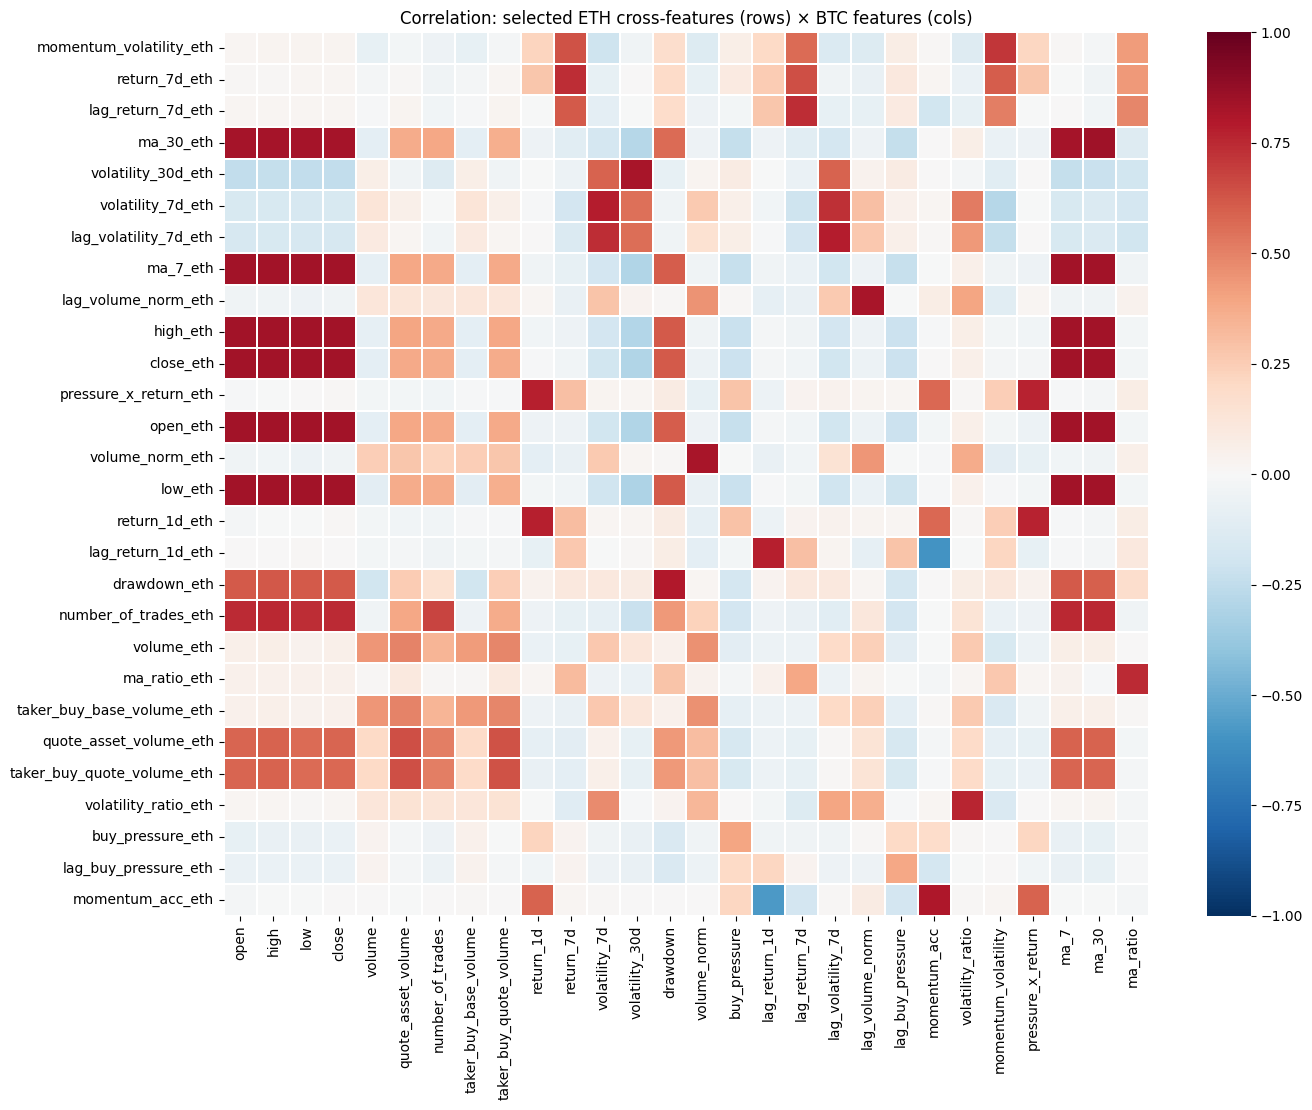

Candidates after combined score ≥ 0.1: 28
Redundant (max |corr| > 0.9): []
Kept after redundancy filter: ['momentum_volatility_eth', 'return_7d_eth', 'lag_return_7d_eth', 'ma_30_eth', 'volatility_30d_eth', 'volatility_7d_eth', 'lag_volatility_7d_eth', 'ma_7_eth', 'lag_volume_norm_eth', 'high_eth', 'close_eth', 'pressure_x_return_eth', 'open_eth', 'volume_norm_eth', 'low_eth', 'return_1d_eth', 'lag_return_1d_eth', 'drawdown_eth', 'number_of_trades_eth', 'volume_eth', 'ma_ratio_eth', 'taker_buy_base_volume_eth', 'quote_asset_volume_eth', 'taker_buy_quote_volume_eth', 'volatility_ratio_eth', 'buy_pressure_eth', 'lag_buy_pressure_eth', 'momentum_acc_eth']


In [23]:
REDUNDANCY_THRESHOLD = 0.9

# Candidates: ETH features that pass the combined score threshold
candidates = cross_score[cross_score >= CROSS_SCORE_THRESHOLD].index.tolist()

# BTC features already in the model
btc_base_cols = [c for c in df_merged.columns if not c.endswith("_eth") and c != "target"]

# Correlation matrix between candidates and BTC features
corr_cross = df_merged[btc_base_cols + candidates].corr(numeric_only=True).loc[candidates, btc_base_cols]

# Heatmap
plt.figure(figsize=(max(12, len(btc_base_cols) * 0.5), max(6, len(candidates) * 0.4)))
sns.heatmap(
    corr_cross,
    annot=False,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
)
plt.title("Correlation: selected ETH cross-features (rows) × BTC features (cols)")
plt.tight_layout()
plt.show()

# Drop ETH features with max absolute correlation > threshold with any BTC feature
redundant = [f for f in candidates if corr_cross.loc[f].abs().max() > REDUNDANCY_THRESHOLD]
non_redundant = [f for f in candidates if f not in redundant]

print(f"Candidates after combined score ≥ {CROSS_SCORE_THRESHOLD}: {len(candidates)}")
print(f"Redundant (max |corr| > {REDUNDANCY_THRESHOLD}): {redundant}")
print(f"Kept after redundancy filter: {non_redundant}")

### 5. Final Dataset for Modeling

In [24]:
# Re-merge cleanly
eth_renamed2 = df_eth.rename(columns={c: f"{c}_eth" for c in df_eth.columns if c != "open_time"})
df_btc_eth = pd.merge(df_btc, eth_renamed2, on="open_time", how="inner")
df_btc_eth.drop(columns=["target_eth", "open_time"], inplace=True)
print(f"Final dataset: {df_btc_eth.shape[0]} rows, {df_btc_eth.shape[1]} columns")
df_btc_eth.columns

Final dataset: 3114 rows, 57 columns


Index(['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
       'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume',
       'return_1d', 'return_7d', 'volatility_7d', 'volatility_30d', 'drawdown',
       'volume_norm', 'buy_pressure', 'lag_return_1d', 'lag_return_7d',
       'lag_volatility_7d', 'lag_volume_norm', 'lag_buy_pressure',
       'momentum_acc', 'volatility_ratio', 'momentum_volatility',
       'pressure_x_return', 'ma_7', 'ma_30', 'ma_ratio', 'target', 'open_eth',
       'high_eth', 'low_eth', 'close_eth', 'volume_eth',
       'quote_asset_volume_eth', 'number_of_trades_eth',
       'taker_buy_base_volume_eth', 'taker_buy_quote_volume_eth',
       'return_1d_eth', 'return_7d_eth', 'volatility_7d_eth',
       'volatility_30d_eth', 'drawdown_eth', 'volume_norm_eth',
       'buy_pressure_eth', 'lag_return_1d_eth', 'lag_return_7d_eth',
       'lag_volatility_7d_eth', 'lag_volume_norm_eth', 'lag_buy_pressure_eth',
       'momentum_acc_eth', 'volat

**Feature Selection**

**BTC market features** are taken from the selection established in notebook 01 (BTC EDA), validated on 3 115 rows with a correlation-based redundancy filter (threshold 0.9).

**ETH cross-features** go through a **two-step selection**:
1. **Combined score ≥ 0.10** (|Spearman| + MI, normalized) — all 28 ETH features pass
2. **Redundancy filter (|corr| > 0.9)** — no ETH feature is highly correlated with any BTC feature already in the model

**Result:** 17 BTC features + 28 ETH cross-features = **45 total features** on **3 114 rows**.

In [25]:
# BTC market features from notebook 01
BTC_FEATURES = [
    "return_1d", "return_7d",
    "volatility_7d", "volatility_30d",
    "buy_pressure",
    "drawdown",
    "ma_ratio",
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume",
]

# ETH cross-features: combined score >= threshold AND not redundant with BTC features
ETH_CROSS_FEATURES = non_redundant

SELECTED_FEATURES = BTC_FEATURES + ETH_CROSS_FEATURES
TARGET = "target"

print(f"BTC features: {len(BTC_FEATURES)}")
print(f"ETH cross-features selected (after redundancy filter): {len(ETH_CROSS_FEATURES)}")
print(f"Total features: {len(SELECTED_FEATURES)}")
print(f"ETH features kept: {ETH_CROSS_FEATURES}")

df_btc_eth = df_btc_eth[SELECTED_FEATURES + [TARGET]]
df_btc_eth.head()

BTC features: 17
ETH cross-features selected (after redundancy filter): 28
Total features: 45
ETH features kept: ['momentum_volatility_eth', 'return_7d_eth', 'lag_return_7d_eth', 'ma_30_eth', 'volatility_30d_eth', 'volatility_7d_eth', 'lag_volatility_7d_eth', 'ma_7_eth', 'lag_volume_norm_eth', 'high_eth', 'close_eth', 'pressure_x_return_eth', 'open_eth', 'volume_norm_eth', 'low_eth', 'return_1d_eth', 'lag_return_1d_eth', 'drawdown_eth', 'number_of_trades_eth', 'volume_eth', 'ma_ratio_eth', 'taker_buy_base_volume_eth', 'quote_asset_volume_eth', 'taker_buy_quote_volume_eth', 'volatility_ratio_eth', 'buy_pressure_eth', 'lag_buy_pressure_eth', 'momentum_acc_eth']


,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,...,volume_eth,ma_ratio_eth,taker_buy_base_volume_eth,quote_asset_volume_eth,taker_buy_quote_volume_eth,volatility_ratio_eth,buy_pressure_eth,lag_buy_pressure_eth,momentum_acc_eth,target
0,0.004041,-0.127702,0.104128,0.060268,0.481585,-0.231640,0.911502,0.160231,-0.136079,0.103904,...,10362.06011,0.850311,3866.60141,2.647152e+06,995005.326705,1.514538,0.373150,0.418015,-0.190181,1
1,-0.004027,-0.104199,0.103943,0.059834,0.401559,-0.234734,0.899889,0.004041,-0.127702,0.104128,...,4614.53337,0.837263,1442.00382,1.149704e+06,360268.473861,1.532832,0.312492,0.373150,0.047636,1
2,0.090546,-0.041217,0.110665,0.062149,0.405472,-0.165443,0.894766,-0.004027,-0.104199,0.103943,...,4125.97051,0.835699,2342.68408,1.182938e+06,669740.521499,1.623058,0.567790,0.312492,0.110688,1
3,-0.030971,-0.060926,0.111239,0.062376,0.285173,-0.191290,0.887418,0.090546,-0.041217,0.110665,...,1869.90852,0.832508,789.82937,5.357736e+05,226839.706542,1.630211,0.422389,0.567790,-0.179622,1
4,-0.002568,-0.011329,0.109144,0.062290,0.548281,-0.193367,0.886718,-0.030971,-0.060926,0.111239,...,1060.56734,0.838497,566.64637,3.027397e+05,162290.418587,1.626730,0.534286,0.422389,0.028841,0


**Observations:**
- The final dataset contains **3 114 rows** and **45 feature columns** + 1 target column.
- **17 BTC market features**: core price, return, volatility, volume, and momentum indicators from notebook 01.
- **28 ETH cross-features**: all ETH market features pass the combined score threshold (≥ 0.10) and none are redundant with BTC features (no pair exceeds 0.9 absolute correlation).
- The complete absence of redundant ETH features is notable: despite the high co-movement between BTC and ETH, their engineered features remain sufficiently distinct at the 0.9 threshold.

**Conclusion:**
The cross-asset dataset is richer than the BTC-only baseline (45 vs. 17 features) with no artificial inflation through correlated duplicates. ETH features complement BTC features rather than replicate them.

### **General Conclusion — EDA BTC Price × ETH Cross-Features**

#### **Key Findings**

| Metric | Top ETH cross-feature | Value |
|---|---|---|
| Mutual Information | `momentum_volatility_eth` | 0.065 |
| Combined score | `momentum_volatility_eth` | 1.145 |
| Features above threshold (0.10) | — | 28 / 28 |
| Redundant with BTC features | — | 0 / 28 |

1. **ETH market dynamics broadly mirror BTC**: all 28 ETH cross-features clear the combined score threshold of 0.10, confirming that ETH market behaviour is informative for BTC crash prediction across all feature categories (return, volatility, volume, momentum, moving averages).
2. **No redundancy with BTC features**: the redundancy check at 0.9 absolute correlation removes zero features — ETH and BTC engineered features remain sufficiently distinct despite asset correlation.
3. **ETH returns and momentum lead the ranking**: `momentum_volatility_eth`, `return_7d_eth`, and `lag_return_7d_eth` are the top three ETH cross-features, all with combined score > 0.89.
4. **BTC remains the primary signal source**: the top BTC MI value (0.154 for `momentum_volatility`) is 2.4× the top ETH cross-feature MI (0.065), confirming BTC's own dynamics are the strongest predictor.

#### **Feature Selection Methodology**

| Feature type | Count | Selection criterion |
|---|---|---|
| BTC market features | 17 | Correlation-based redundancy filter from notebook 01 (threshold 0.9) |
| ETH cross-features | 28 | Combined score (|Spearman| + MI, normalized) ≥ **0.10** + no redundancy with BTC (|corr| ≤ 0.9) |
| **Total** | **45** | |

#### **Final Feature Set**

**BTC features (17):**
`return_1d`, `return_7d`, `volatility_7d`, `volatility_30d`, `buy_pressure`, `drawdown`, `ma_ratio`, `lag_return_1d`, `lag_return_7d`, `lag_volatility_7d`, `lag_buy_pressure`, `lag_volume_norm`, `momentum_acc`, `momentum_volatility`, `volume`, `number_of_trades`, `quote_asset_volume`

**ETH cross-features (28):**
`momentum_volatility_eth`, `return_7d_eth`, `lag_return_7d_eth`, `ma_30_eth`, `volatility_30d_eth`, `volatility_7d_eth`, `lag_volatility_7d_eth`, `ma_7_eth`, `lag_volume_norm_eth`, `high_eth`, `close_eth`, `pressure_x_return_eth`, `open_eth`, `volume_norm_eth`, `low_eth`, `return_1d_eth`, `lag_return_1d_eth`, `drawdown_eth`, `number_of_trades_eth`, `volume_eth`, `ma_ratio_eth`, `taker_buy_base_volume_eth`, `quote_asset_volume_eth`, `taker_buy_quote_volume_eth`, `volatility_ratio_eth`, `buy_pressure_eth`, `lag_buy_pressure_eth`, `momentum_acc_eth`

#### **Conclusion**
ETH cross-features provide broad complementary signal for BTC crash prediction. The complete overlap of ETH features above the 0.10 threshold, combined with the absence of any redundant pair, suggests that the cross-asset feature set is both comprehensive and non-redundant. The BTC+ETH model (45 features, 3 114 rows) is well-positioned for the benchmark phase.